In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import shap
import dalex as dx
from collections import defaultdict

# XGBoost

## Data Preprocessing

In [2]:
data = pd.read_csv("dataset_refining/german_credit_data_with_risk.csv")

# Missing values are present in "Checking account" and "Saving accounts". They directly link to 0$, hence we replace them with 0s
data = data.fillna(0)

# Using sex hurts model performance, while also adds unnecessary bias, so we remove it
data.drop(columns=["Sex"], inplace=True)

purpose_map = {
    "radio/TV": 0,
    "car": 0,
    "vacation/others": 0,
    "furniture/equipment": 1,
    "repairs": 1,
    "domestic appliances": 1,
    "education": 2,
    "business": 2
}
data["Purpose"] = data["Purpose"].map(purpose_map)

data.replace({"Checking account": {"little": 1, "moderate": 2, "rich": 3}}, inplace=True)
data.replace({"Saving accounts":  {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}}, inplace=True)
data.replace({"Housing":          {"free": 0, "rent": 1, "own": 2}}, inplace=True)
data["credit_risk"] = data["credit_risk"].map({1: 1, 2: 0})   # good=1, bad=0

data = data.astype({
    "Saving accounts": "int",
    "Checking account": "int",
    "Housing": "int"
})

/tmp/ipykernel_119615/1089702627.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Checking account": {"little": 1, "moderate": 2, "rich": 3}}, inplace=True)
/tmp/ipykernel_119615/1089702627.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Saving accounts":  {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}}, inplace=True)
/tmp/ipykernel_119615/1089702627.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

In [3]:
X = data.drop(columns=["credit_risk"])
y = data["credit_risk"]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
for col in data.columns:
    unique_vals = sorted(data[col].unique())
    if len(unique_vals) <= 10:
        print(f"{col:<20} {[int(v) for v in unique_vals]}")
    else:
        print(f"{col:<20} min={data[col].min()}  max={data[col].max()}  ({len(unique_vals)} unique values)")

Age                  min=19  max=75  (53 unique values)
Job                  [0, 1, 2, 3]
Housing              [0, 1, 2]
Saving accounts      [0, 1, 2, 3, 4]
Checking account     [0, 1, 2, 3]
Credit amount        min=250  max=18424  (921 unique values)
Duration             min=4  max=72  (33 unique values)
Purpose              [0, 1, 2]
credit_risk          [0, 1]


## Training

In [5]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False);

## Global Results

In [6]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 40)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")
print("=" * 40)

  Accuracy : 0.8050
  F1 Score : 0.8696
  AUC      : 0.7805


In [7]:
n_rounds = model.n_estimators

acc_train, acc_test = [], []
f1_train,  f1_test  = [], []
auc_train, auc_test = [], []

for i in range(1, n_rounds + 1):
    # --- TRAIN ---
    y_proba_tr = model.predict_proba(X_train, iteration_range=(0, i))[:, 1]
    y_pred_tr  = (y_proba_tr >= 0.5).astype(int)

    acc_train.append(accuracy_score(y_train, y_pred_tr))
    f1_train.append(f1_score(y_train, y_pred_tr))
    auc_train.append(roc_auc_score(y_train, y_proba_tr))

    # --- TEST ---
    y_proba_te = model.predict_proba(X_test, iteration_range=(0, i))[:, 1]
    y_pred_te  = (y_proba_te >= 0.5).astype(int)

    acc_test.append(accuracy_score(y_test, y_pred_te))
    f1_test.append(f1_score(y_test, y_pred_te))
    auc_test.append(roc_auc_score(y_test, y_proba_te))

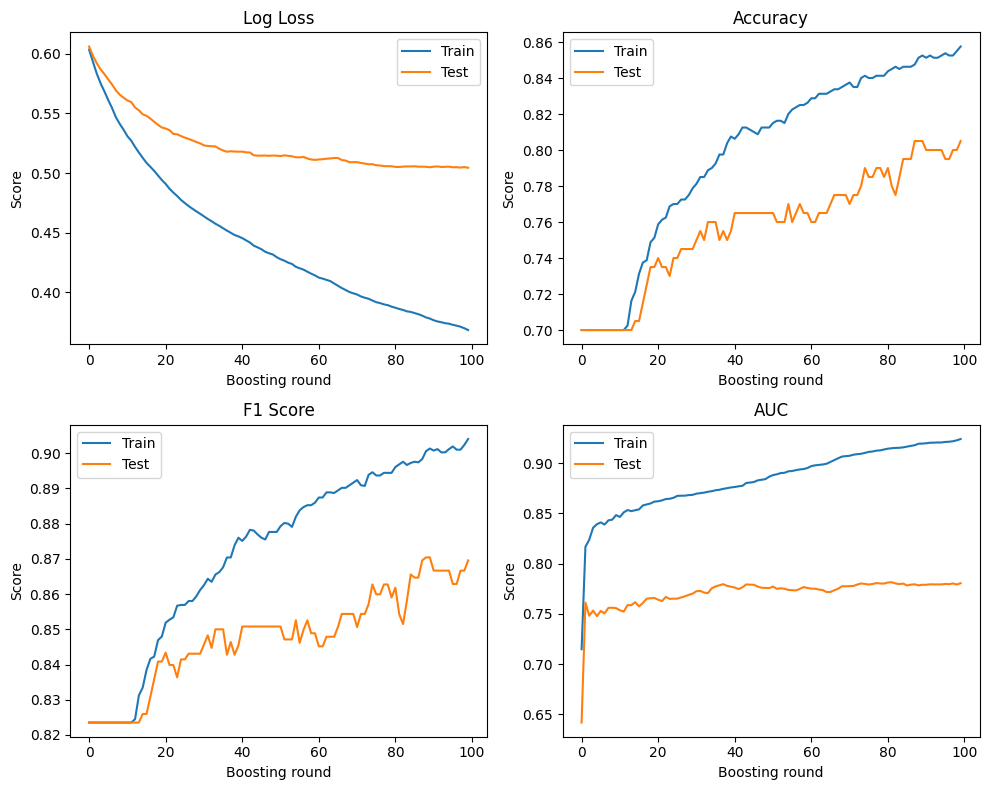

In [8]:
results = model.evals_result()
train_loss = results["validation_0"]["logloss"]
test_loss  = results["validation_1"]["logloss"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# --- Logloss ---
axs[0, 0].plot(train_loss, label="Train")
axs[0, 0].plot(test_loss, label="Test")
axs[0, 0].set_title("Log Loss")
axs[0, 0].legend()

# --- Accuracy ---
axs[0, 1].plot(acc_train, label="Train")
axs[0, 1].plot(acc_test, label="Test")
axs[0, 1].set_title("Accuracy")
axs[0, 1].legend()

# --- F1 ---
axs[1, 0].plot(f1_train, label="Train")
axs[1, 0].plot(f1_test, label="Test")
axs[1, 0].set_title("F1 Score")
axs[1, 0].legend()

# --- AUC ---
axs[1, 1].plot(auc_train, label="Train")
axs[1, 1].plot(auc_test, label="Test")
axs[1, 1].set_title("AUC")
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

The loss and metrics are slightly lower on training set than on the test set, indicating mild overfitting, but test performance remains strong.

### XGBoost feature importance

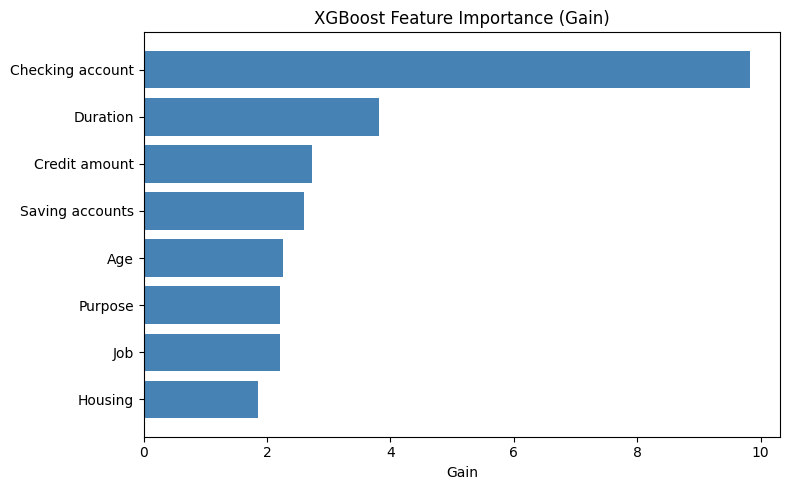

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
importance = model.get_booster().get_score(importance_type="gain")
importance = dict(sorted(importance.items(), key=lambda x: x[1]))
ax.barh(list(importance.keys()), list(importance.values()), color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

The feature importance plot shows that ‘Checking account’ contributes the most to model predictions, followed by ‘Duration’, ‘Saving accounts’, and ‘Credit amount’. Other features such as ‘Age’, ‘Purpose’, ‘Housing’, and ‘Job’ have moderate influence. This ranking aligns with expectations, as financial history and account balances are key factors in predicting credit risk.

### Confusion matrix

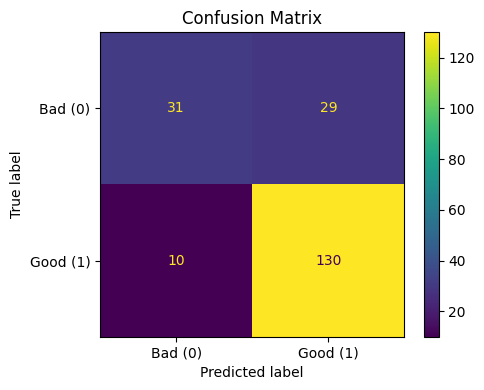

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Bad (0)", "Good (1)"], ax=ax
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly predicts most ‘Good’ cases (130/140) and a smaller portion of ‘Bad’ cases (31/60). Misclassifications occur mostly when a ‘Bad’ credit is predicted as ‘Good’ (28 cases). Overall, the model performs well, with better accuracy on the majority class (‘Good’), and mild overfitting does not appear to affect class separation significantly.

### SHAP summary

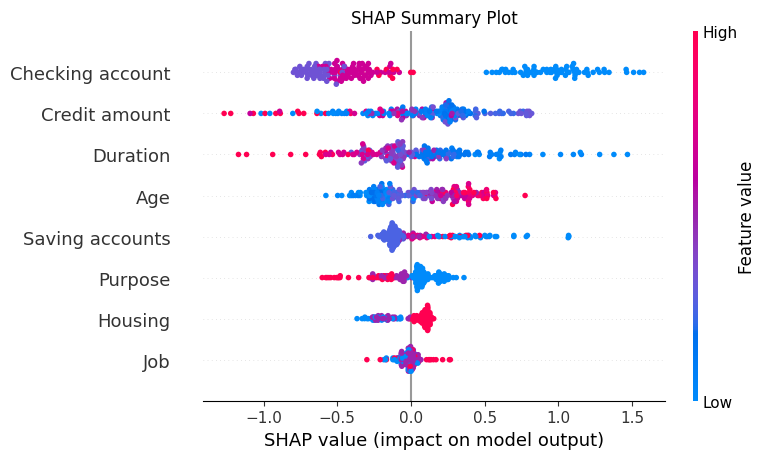

In [11]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

- **Checking account** - surprisingly, a value of `0` (no recorded checking account) contributes positively to good credit risk-likely reflecting individuals who maintain accounts in other banks or have alternative financial arrangements. Small or moderate balances are associated with higher risk, high balances are almost positive.
- **Credit amount** - values are not so well separated, but high values have a very clear negative impact while moderately low values a positive impact. Low values are around `0` likely because for someone with low credit, it is more likely that this low credit is all he can get.
- **Duration** - values in the middle are mixed up, but extremes tell the clear story, long = bad, short = good
- **Age** - Generally higher = better, with experience people generally advance their careers, build their own capital and have greater stability in life
- **Saving Accounts** - here 0 reffers to no saving account and it correlates positively with good risk maybe because those people invest their money outside banks and it serves them better, on the other hand people with rich saving accounts also score well which is obvious. Most people have little money on saving accounts and the model penalizes it slightly
- **Housing** - free or rented is a bad sign, own is a good sign because of greater stability
- **Purpose** - Here high and middle values reffer to ambitious and necessary purposes like school are repairs, it may be that people who take these loans are in a bad position in their life which correlates with bad risk, people who take their loans recklessly for cars and holidays are often in a more stable position
- **Job** - Generally better job is better (lower) credit risk

### SHAP feature importance

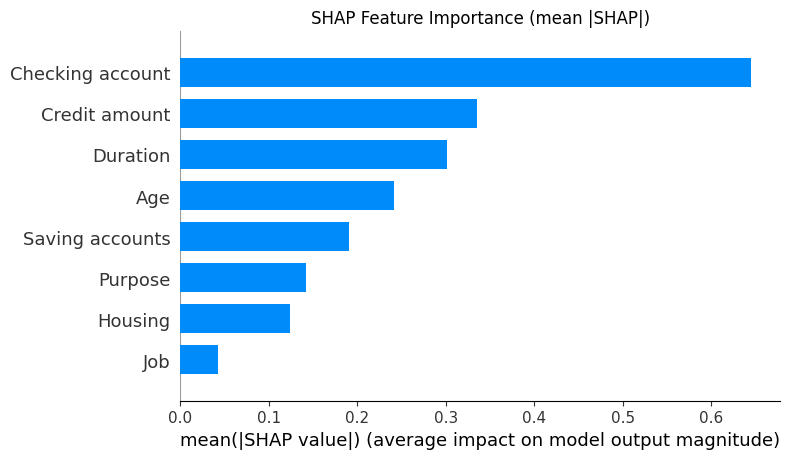

In [12]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

The SHAP feature importance shows that `Checking account` is by far the most influential feature, significantly exceeding all others. It is followed by `Credit amount` and `Duration`, indicating that the model relies primarily on financial attributes. `Age` and `Saving accounts` have moderate importance, while `Housing`, `Purpose`, and especially `Job` contribute relatively little to the model's predictions.

## Sample Analysis

In [13]:
def plot_shap_waterfall(model, sample):
    # Ensure we have an explainer
    explainer = shap.TreeExplainer(model)

    # compute SHAP values for the sample
    shap_values = explainer.shap_values(sample)

    print(shap_values)

    # get index 0 because it's a single-row DataFrame
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[0],
        feature_names=sample.columns,
        max_display=10
    )

    logit = explainer.expected_value + shap_values.sum()
    delta_logit = 0 - logit  # amount needed to flip class
    print(f"Current class: {int(logit > 0)}, amount needed to flip the class: {delta_logit:.4f}")

### Analytical functions

The analytical approach identifies the minimum change by traversing the decision paths of all 100 trees and collecting every split threshold each feature appears at. For each feature, the nearest threshold crossing that - when tested against the full model - actually flips the predicted class is reported as the minimum change. This is minimal by construction: any smaller change would leave all tree paths unchanged and therefore cannot alter the prediction.

In [14]:
def infer_feature_ranges(X_data):
    """
    Infer (min, max, step) for each feature from the dataset.
    Integer-valued columns get step=1, continuous get step based on range.
    """
    ranges = {}
    for feature in X_data.columns:
        col = X_data[feature]
        f_min = col.min()
        f_max = col.max()
        
        # Check if column contains only whole numbers -> treat as integer/ordinal
        if (col == col.round()).all():
            step = 1
        else:
            # Continuous: use median gap between sorted unique values
            unique_sorted = np.sort(col.unique())
            if len(unique_sorted) > 1:
                step = np.median(np.diff(unique_sorted))
            else:
                step = 1
        
        ranges[feature] = (f_min, f_max, step)
    
    return ranges

def find_minimum_flip_per_feature(xgb_clf, X_instance_row, IDX):
    original_class = int(xgb_clf.predict(X_instance_row)[0])
    original_proba = xgb_clf.predict_proba(X_instance_row)[0]
    original_label = 'good' if original_class == 1 else 'bad'
    print(f"Instance #{IDX}  |  Predicted: {original_label} credit  (p_good = {original_proba[1]:.4f})\n")

    booster  = xgb_clf.get_booster()
    trees_df = booster.trees_to_dataframe()
    instance_values = X_instance_row.iloc[0].to_dict()

    # Infer ranges from the data passed in
    feature_ranges = {}
    for feature in X_instance_row.columns:
        col = X_instance_row._mgr  # use the full dataset instead
    feature_ranges = infer_feature_ranges(X_train)  # reuse infer function

    # Collect all thresholds per feature per direction across all trees
    thresholds = defaultdict(lambda: {'increase': [], 'decrease': []})
    n_trees = trees_df['Tree'].max() + 1

    for tree_idx in range(n_trees):
        tree = trees_df[trees_df['Tree'] == tree_idx]
        node_lookup = {row['Node']: row for _, row in tree.iterrows()}
        current_node = 0

        while True:
            node = node_lookup[current_node]
            if node['Feature'] == 'Leaf':
                break
            feature   = node['Feature']
            threshold = node['Split']
            val       = instance_values[feature]
            went_left = val < threshold

            if went_left:
                new_val = np.ceil(threshold) if feature_ranges[feature][2] == 1 else threshold
                if new_val > val:
                    thresholds[feature]['increase'].append(new_val)
            else:
                new_val = np.floor(threshold)-1 if feature_ranges[feature][2] == 1 else threshold
                if new_val < val:
                    thresholds[feature]['decrease'].append(new_val)

            current_node = int(node['Yes'].split('-')[1]) if went_left \
                      else int(node['No'].split('-')[1])

    for feature in thresholds:
        thresholds[feature]['increase'] = sorted(set(thresholds[feature]['increase']))
        thresholds[feature]['decrease'] = sorted(set(thresholds[feature]['decrease']), reverse=True)

    # For each feature find the best (smallest abs delta) flip across both directions
    best_per_feature = {}

    for feature in X_instance_row.columns:
        val = instance_values[feature]
        feat_min, feat_max, step = feature_ranges[feature]
        best = {'delta': None, 'new_value': None}

        for direction, candidates in thresholds.get(feature, {}).items():
            for new_val in candidates:
                new_val = np.clip(new_val, feat_min, feat_max)
                X_new = X_instance_row.copy()
                X_new[feature] = new_val
                # Calling predict here is a shortcut for manually summing all leaf weights
                # across all 100 trees for the modified instance - mathematically equivalent
                # to computing the score change from crossing this threshold analytically
                if int(xgb_clf.predict(X_new)[0]) != original_class:
                    delta = new_val - val
                    if best['delta'] is None or abs(delta) < abs(best['delta']):
                        best = {'delta': delta, 'new_value': new_val}
                    break  # candidates are sorted nearest-first

        best_per_feature[feature] = {
            'current':  val,
            'flip_to':  best['new_value'],
            'delta':    best['delta'],
        }

    return best_per_feature, original_proba[1]


def print_flip_table_analytical(best_per_feature, p_good):
    SEP = "─" * 54
    FMT = "{:<20} {:>8} {:>10} {:>10}"
    print(SEP)
    print(FMT.format("Feature", "Current", "Flip to", "Delta"))
    print(SEP)
    for feature, r in best_per_feature.items():
        if r['flip_to'] is None:
            print(FMT.format(feature, str(r['current']), "—", "—"))
        else:
            print(FMT.format(feature, str(r['current']),
                             f"{r['flip_to']:.2f}", f"{r['delta']:+.2f}"))
    print(SEP)
    print(f"p_good = {p_good:.4f}")

### Sampling functions

In [15]:
def minimal_flip(model, X_test, idx, feature, max_steps=100, step_fraction=0.01, direction=1):
    X_sample = X_test.iloc[[idx]].copy()
    original_class = model.predict(X_sample)[0]
    
    # Determine step size
    if X_sample[feature].dtype.kind in 'iuf':  # numeric
        step = step_fraction * (X_test[feature].max() - X_test[feature].min())
        if X_sample[feature].dtype.kind in 'i':
            step = max(1, round(step))
    else:  # categorical
        step = 1
    
    # Iteratively perturb
    sample_cf = X_sample.copy()
    for i in range(1, max_steps + 1):
        if X_sample[feature].dtype.kind in 'iuf':
            sample_cf[feature] += step * direction
        else:
            # for categorical: move to next ordinal category
            sample_cf[feature] = int(sample_cf[feature] + step * direction)
        
        new_class = model.predict(sample_cf)[0]
        if new_class != original_class:
            return {
                'original_class': original_class,
                'flipped_class': new_class,
                'feature': feature,
                'total_change': step * i,
                'steps': i,
                'sample_cf': sample_cf
            }
    
    # If not flipped
    return {
        'original_class': original_class,
        'flipped_class': original_class,
        'feature': feature,
        'total_change': 0,
        'steps': 0,
        'sample_cf': sample_cf
    }

def minimal_flip_all(model, X_data, idx, max_steps=200, step_fraction=0.01):
    row            = X_data.iloc[[idx]]
    original_pred  = model.predict(row)[0]
    original_proba = model.predict_proba(row)[0]
    original_label = 'good' if original_pred == 1 else 'bad'
    print(f"Instance #{idx}  |  Predicted: {original_label} credit  (p_good = {original_proba[1]:.4f})\n")

    records = []
    for feature in X_data.columns:
        current_val = row[feature].values[0]
        best = {'total_change': None, 'new_value': None}

        for direction in (+1, -1):
            res = minimal_flip(model, X_data, idx, feature,
                               max_steps=max_steps,
                               step_fraction=step_fraction,
                               direction=direction)

            # flipped only if flipped_class != original_class
            if res['flipped_class'] != res['original_class']:
                change = res['total_change'] * direction  # preserve sign
                if best['total_change'] is None or abs(change) < abs(best['total_change']):
                    best['total_change'] = change
                    best['new_value']    = current_val + change

        records.append({
            'feature': feature,
            'current': current_val,
            'flip_to': best['new_value'],
            'delta':   best['total_change'],
        })

    return pd.DataFrame(records)

def print_flip_table_sampling(df, p_good):
    SEP = "─" * 54
    FMT = "{:<20} {:>8} {:>10} {:>10}"
    print(SEP)
    print(FMT.format("Feature", "Current", "Flip to", "Delta"))
    print(SEP)
    for _, r in df.iterrows():
        if r['flip_to'] is None or (isinstance(r['flip_to'], float) and np.isnan(r['flip_to'])):
            print(FMT.format(r['feature'], str(r['current']), "—", "—"))
        else:
            print(FMT.format(r['feature'], str(r['current']),
                             f"{r['flip_to']:.2f}", f"{r['delta']:+.2f}"))
    print(SEP)
    print(f"p_good = {p_good:.4f}")

### Sample selection

In [16]:
# predicted probabilities for class 1 (Good)
probas = model.predict_proba(X_test)[:, 1]
preds  = model.predict(X_test)

idx_1 = 15
idx_2 = 73
idx_3 = 118

print(f"Probability {idx_1}:", probas[idx_1])
print(f"Probability {idx_2}:", probas[idx_2])
print(f"Probability {idx_3}:", probas[idx_3])

Probability 15: 0.5178642
Probability 73: 0.56484336
Probability 118: 0.51054645


### Sample 15

In [17]:
IDX = 15
sample = X_test.iloc[[IDX]].copy()

#### Analytical

In [18]:
best_per_feature, p_good = find_minimum_flip_per_feature(model, sample, IDX)
print_flip_table_analytical(best_per_feature, p_good)

Instance #15  |  Predicted: good credit  (p_good = 0.5179)

──────────────────────────────────────────────────────
Feature               Current    Flip to      Delta
──────────────────────────────────────────────────────
Age                        26      27.00      +1.00
Job                         2       1.00      -1.00
Housing                     2       1.00      -1.00
Saving accounts             1          —          —
Checking account            3       2.00      -1.00
Credit amount            1925    1373.00    -552.00
Duration                   24      30.00      +6.00
Purpose                     1          —          —
──────────────────────────────────────────────────────
p_good = 0.5179


#### Sampling

In [19]:
original_proba = model.predict_proba(sample)[0]
df_flips = minimal_flip_all(model, X_test, IDX, max_steps=100, step_fraction=0.01)
print_flip_table_sampling(df_flips, original_proba[1])

Instance #15  |  Predicted: good credit  (p_good = 0.5179)

──────────────────────────────────────────────────────
Feature               Current    Flip to      Delta
──────────────────────────────────────────────────────
Age                        26      27.00      +1.00
Job                         2       1.00      -1.00
Housing                     2       1.00      -1.00
Saving accounts             1          —          —
Checking account            3       2.00      -1.00
Credit amount            1925    1305.00    -620.00
Duration                   24      30.00      +6.00
Purpose                     1          —          —
──────────────────────────────────────────────────────
p_good = 0.5179


Both methods agree perfectly on all ordinal features. For `Age`, `Job`, `Housing`, and `Checking account` a single category step is sufficient to flip the class - this is the smallest possible change for discrete features. `Saving accounts` and `Purpose` cannot flip the class regardless of their value, meaning no threshold crossing for these features alone is enough to overcome the remaining score margin.

For `Credit amount` the methods diverge slightly - analytical finds the exact tree threshold at 1373, while sampling lands at 1305 due to the fixed step size overshooting the true boundary. Both correctly identify the direction and order of magnitude. `Duration` agrees exactly at 30 months in both.

#### Decision / prediction explanation

In [20]:
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
248,26,2,2,1,3,1925,24,1


[[-0.15041098  0.02091877  0.09410615 -0.14921801 -0.16712937 -0.06132998
  -0.32480326 -0.04361908]]


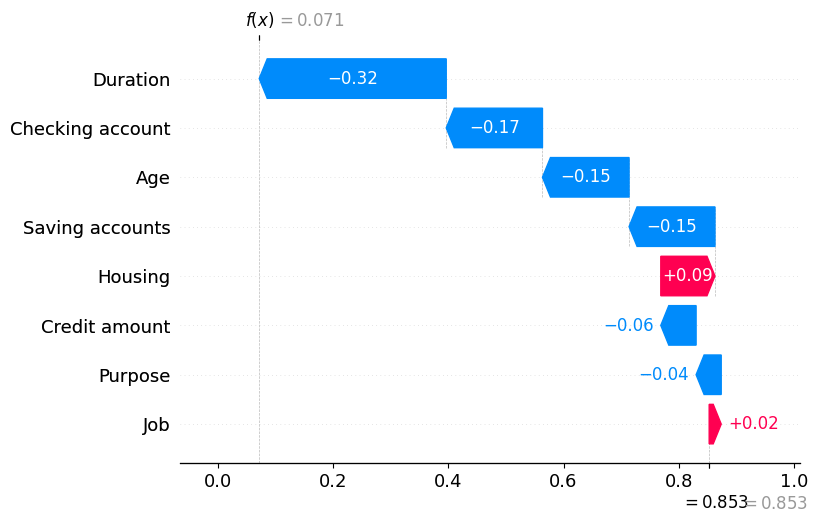

Current class: 1, amount needed to flip the class: -0.0715


In [21]:
plot_shap_waterfall(model, X_test.iloc[[15]])

`Housing = 2` (own) and `Job = 2` (skilled), are the only positive contributors, due to their low relevance they don't contribute much, the rest of attributes have negative impact, though not negative enough to push the high base on the negative side on the shap waterfall plot.

`Duration = 24` (months) has the single most negative contribution, 24 months is not so bad and hence the negative SHAP value is only moderate.

`Checking account = 3` (rich) - important criterion slightly negative value alligned with SHAP summary despite the misleading meaning behind the word **rich**. The applicant is young `Age = 26` - the model has learned that younger applicants haven't yet accumulated career stability or capital and `Saving accounts = 1` (little) is a mild negative.

The `Credit amount` (1925) is on the lower end - but not extreme enough to strongly penalise. `Purpose = 1` (furniture/repairs) is slightly penalised, possibly associated with financial strain.

This person is borderline good credit - no single feature is strongly positive, but also no feature is extreme enough to overcome the high base value. A worse checking account, longer duration, or older loan purpose would likely push them into bad credit

### Sample 73

In [22]:
IDX = 73
sample = X_test.iloc[[IDX]].copy()

#### Analytical

In [23]:
best_per_feature, p_good = find_minimum_flip_per_feature(model, sample, IDX)
print_flip_table_analytical(best_per_feature, p_good)

Instance #73  |  Predicted: good credit  (p_good = 0.5648)

──────────────────────────────────────────────────────
Feature               Current    Flip to      Delta
──────────────────────────────────────────────────────
Age                        43      34.00      -9.00
Job                         1          —          —
Housing                     2       1.00      -1.00
Saving accounts             1          —          —
Checking account            1          —          —
Credit amount            1344    1023.00    -321.00
Duration                   12      16.00      +4.00
Purpose                     0          —          —
──────────────────────────────────────────────────────
p_good = 0.5648


#### Sampling

In [24]:
original_proba = model.predict_proba(sample)[0]
df_flips = minimal_flip_all(model, X_test, IDX, max_steps=200, step_fraction=0.01)
print_flip_table_sampling(df_flips, original_proba[1])

Instance #73  |  Predicted: good credit  (p_good = 0.5648)

──────────────────────────────────────────────────────
Feature               Current    Flip to      Delta
──────────────────────────────────────────────────────
Age                        43      34.00      -9.00
Job                         1          —          —
Housing                     2       1.00      -1.00
Saving accounts             1          —          —
Checking account            1          —          —
Credit amount            1344     879.00    -465.00
Duration                   12      16.00      +4.00
Purpose                     0          —          —
──────────────────────────────────────────────────────
p_good = 0.5648


Both methods agree exactly on all ordinal and integer features. `Housing` flips with a single category step, and `Duration` requires an increase of just 4 months - both confirmed identically.

`Age` requires a reduction of 9 years to 34 in both methods - a larger change compared to sample 15, consistent with the higher confidence margin (p_good=0.565). The model has multiple age-related thresholds in this region, and the boundary sits at a point where the accumulated score across all trees tips over.

`Job`, `Saving accounts`, `Checking account`, and `Purpose` show no flip - notably `Checking account` is already at its worst value (1 = little), so no downward change is possible, and no upward change alone is sufficient to flip the class given the other feature values.

For `Credit amount` the methods diverge - analytical finds the exact threshold at 1023, sampling overshoots to 879 due to step size. Both agree on direction.

Compared to sample 15, fewer features can independently flip the class, reflecting the greater distance from the boundary. Only features where the model has learned strong thresholds close to the current values are effective - `Age` and `Duration` in this case carry enough individual weight to cross the margin alone.

#### Decision / prediction explanation

In [25]:
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
929,43,1,2,1,1,1344,12,0


[[ 0.1758665  -0.00430871  0.11730138 -0.09601919 -0.7545011  -0.2877691
   0.19933103  0.05796834]]


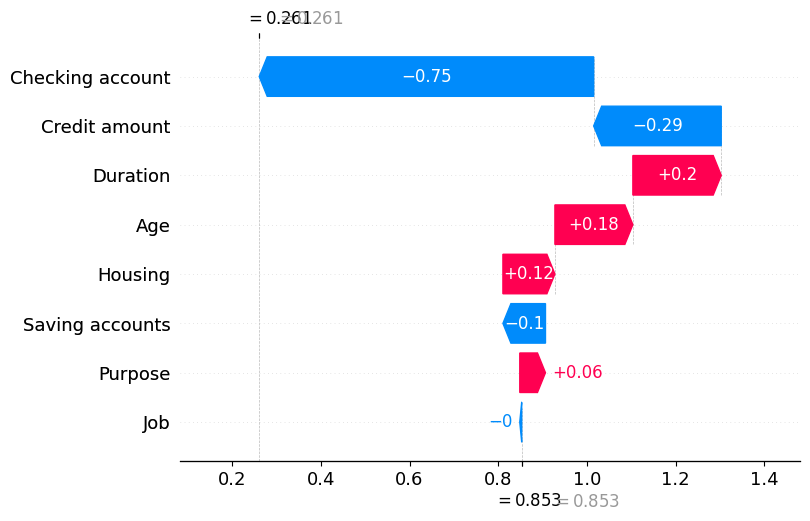

Current class: 1, amount needed to flip the class: -0.2608


In [26]:
plot_shap_waterfall(model, X_test.iloc[[IDX]])

The applicant is a 43-year-old unskilled resident who owns their home and is applying for a 1344 loan over 12 months for leisure/consumer purposes.

`Duration = 12` (short loan) is the strongest positive signal - the model strongly favours short repayment periods as they indicate lower exposure risk. `Age = 43` follows closely, at this age the model expects accumulated stability and capital. `Housing = 2` (own) further reinforces good credit, and `Purpose = 0` (car/leisure) carries a slight positive, consistent with the pattern that discretionary borrowers tend to be in more stable financial positions.

However, `Checking account = 1` (little) is overwhelmingly negative (-0.75 SHAP), single-handedly dragging the prediction toward bad credit and cancelling all positive contributions combined. `Credit amount = 1344` adds a moderate additional penalty. `Saving accounts = 1` (little) contributes a mild further negative.

The model predicts **good credit** (class=1), but with a margin of only 0.26 from flipping — this person is one step away from bad credit classification, entirely due to the checking account status. A richer checking account would likely shift the prediction comfortably into good credit territory.

### Sample 118

In [27]:
IDX = 118
sample = X_test.iloc[[IDX]].copy()

#### Analytical

In [28]:
best_per_feature, p_good = find_minimum_flip_per_feature(model, sample, IDX)
print_flip_table_analytical(best_per_feature, p_good)

Instance #118  |  Predicted: good credit  (p_good = 0.5105)

──────────────────────────────────────────────────────
Feature               Current    Flip to      Delta
──────────────────────────────────────────────────────
Age                        55      60.00      +5.00
Job                         2          —          —
Housing                     2       1.00      -1.00
Saving accounts             1          —          —
Checking account            1          —          —
Credit amount            6872    8358.00   +1486.00
Duration                   24      28.00      +4.00
Purpose                     1       2.00      +1.00
──────────────────────────────────────────────────────
p_good = 0.5105


#### Sampling

In [29]:
original_proba = model.predict_proba(sample)[0]
df_flips = minimal_flip_all(model, X_test, IDX, max_steps=200, step_fraction=0.01)
print_flip_table_sampling(df_flips, original_proba[1])

Instance #118  |  Predicted: good credit  (p_good = 0.5105)

──────────────────────────────────────────────────────
Feature               Current    Flip to      Delta
──────────────────────────────────────────────────────
Age                        55      60.00      +5.00
Job                         2          —          —
Housing                     2       1.00      -1.00
Saving accounts             1          —          —
Checking account            1          —          —
Credit amount            6872    8422.00   +1550.00
Duration                   24      28.00      +4.00
Purpose                     1       2.00      +1.00
──────────────────────────────────────────────────────
p_good = 0.5105


Both methods agree exactly on all ordinal and categorical features. `Housing`, `Duration`, and `Purpose` each require a single step, and `Age` requires an increase of 5 years - all confirmed identically by both methods.

A notable difference from the previous samples is that all flips here go in the positive direction - older age, longer duration, higher credit amount, worse purpose category all push toward bad credit. This reflects the particular feature profile: the applicant is already at unfavourable values for `Checking account` and `Saving accounts`, so the model is being tipped over by worsening the features that were previously holding it in good credit territory.

`Job`, `Saving accounts`, and `Checking account` show no flip - same as sample 73, `Checking account` is already at its minimum value and no single feature change can compensate for it alone.

For `Credit amount` both methods agree on direction but diverge in value — analytical finds the exact tree threshold at 8358, sampling overshoots slightly to 8422. The required increase is large (~1500) compared to the current value, indicating the model considers this loan amount already penalised but not yet at a critical threshold.

Across all three samples, the analytical and sampling methods are fully consistent on discrete features, with minor divergence on `Credit amount` attributable purely to step size. The analytical method is exact by construction, while sampling trades precision for simplicity.

#### Decision / prediction explanation

In [30]:
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
924,55,2,2,1,1,6872,24,1


[[ 0.21740887 -0.03126844  0.0831841  -0.13564076 -0.59376204 -0.19198671
  -0.09379566 -0.06492037]]


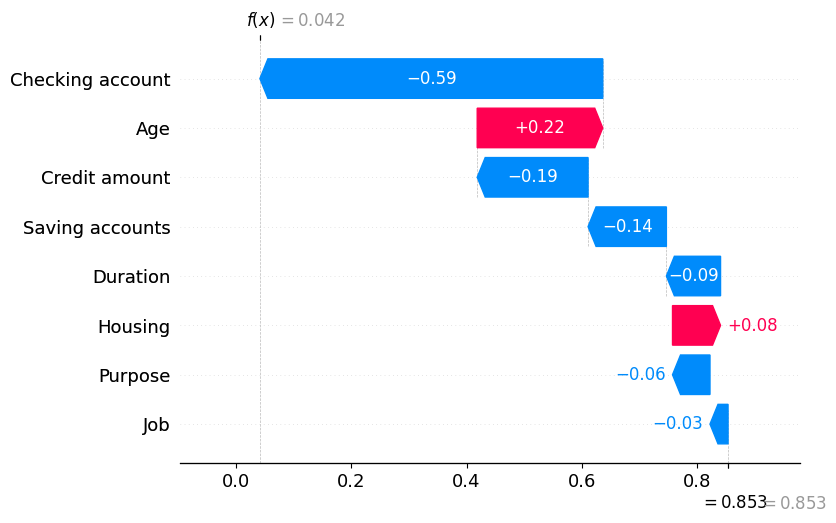

Current class: 1, amount needed to flip the class: -0.0422


In [31]:
plot_shap_waterfall(model, X_test.iloc[[IDX]])

`Age = 55` is the strongest positive - at this age the model expects well-established career, capital and life stability. `Housing = 2` (own) adds a moderate positive reinforcing that stability.

Everything else pulls toward bad credit. `Checking account = 1` (little) again dominates as the single largest negative (-0.59 SHAP), entirely cancelling the age advantage alone. `Credit amount = 6872` is a meaningful negative - unlike the previous sample, this loan is large enough to clearly penalise. `Saving accounts = 1` (little) compounds the concern around financial reserves. `Duration = 24` and `Purpose = 1` (furniture/repairs) add further moderate negatives, the latter again consistent with borrowing under financial strain.

This is the most borderline of the three samples - only 0.04 from flipping. The profile is paradoxical: a mature, stable homeowner whose good credit classification hangs by a thread entirely because of a weak checking account and a loan that is too large for the model's comfort. Any slight worsening of either would flip the class.

## Interpretation of the model

In [32]:
explainer = dx.Explainer(
    model,
    X_test,
    y_test,
    label="XGBoost"
)

Preparation of a new explainer is initiated

  -> data              : 200 rows 8 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 200 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : XGBoost
  -> predict function  : <function yhat_proba_default at 0x7f937ae694e0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.2, mean = 0.691, max = 0.977
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.965, mean = 0.0089, max = 0.743
  -> model_info        : package xgboost

A new explainer has been created!


### Q1

Based on the parameters obtained, can we say something about the user’s preferences?

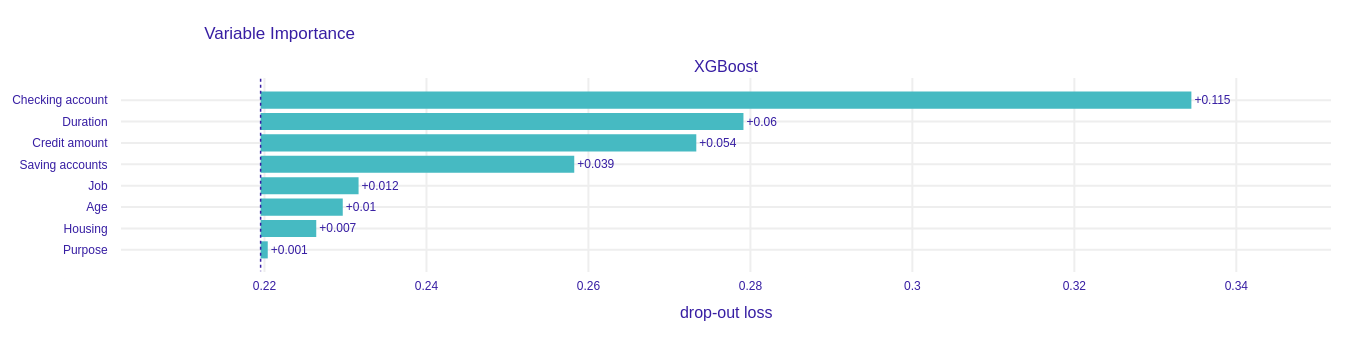

In [33]:
# Global feature importance
vi = explainer.model_parts()
vi.plot()

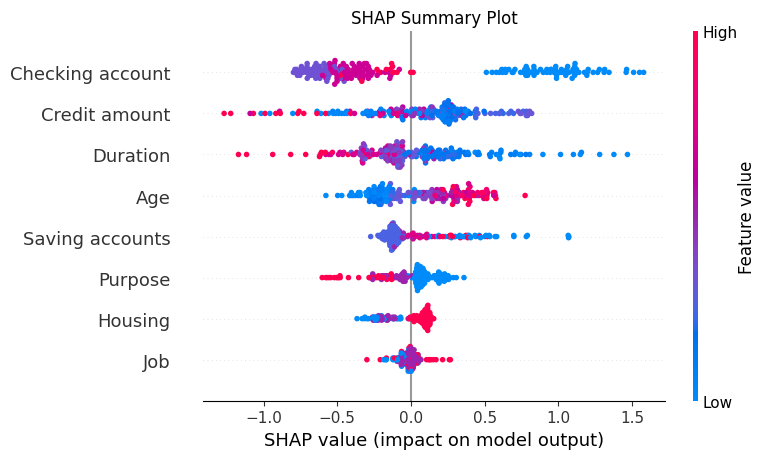

In [34]:
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

Based on the model parameters and interpretation techniques, we can infer that the decision-maker exhibits a risk-averse preference structure.

The most influential criteria - `Checking account`, `Credit amount`, and `Duration` - indicate that liquidity and debt burden are the primary drivers of decisions. `Credit amount` and `Duration` act as cost criteria, where higher values significantly decrease the likelihood of a favorable classification, while `Age` and `Housing` behave as gain criteria, reflecting preference for stability and experience.

The model also captures nonlinear and threshold-based preferences, particularly for `Duration`, where longer loan periods sharply increase risk. Additionally, some criteria, such as `Saving accounts` and `Checking account`, exhibit non-monotonic behavior, suggesting either complex interactions or dataset-specific effects rather than clear economic preferences.

The relatively low importance of `Purpose`, `Job`, and `Housing` indicates that these factors play a secondary role in the decision process.

Overall, the inferred preferences prioritize financial stability, low indebtedness, and shorter financial commitments, reflecting a conservative and risk-sensitive decision policy.

### Q2

What was the influence of the criteria? Are there any criteria that have no effect, or have a decisive influence?

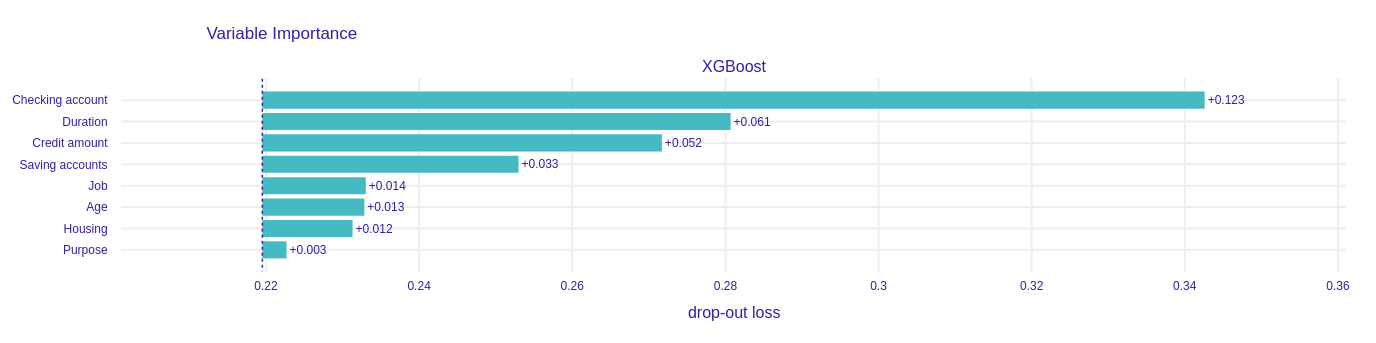

In [35]:
# Global feature importance
vi = explainer.model_parts()
vi.plot()

Based on permutation feature importance (DALEX), the most influential criteria are **Checking account**, **Duration**, **Credit amount** and **Saving accounts** as removing them leads to the largest increase in model error. These variables can therefore be considered decisive for the model’s predictions.

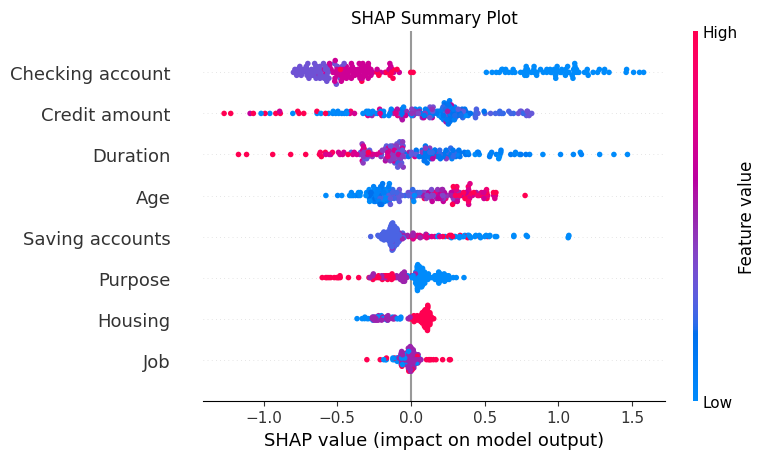

In [36]:
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

This is consistent with SHAP analysis, where these features exhibit the largest spread of SHAP values, indicating a strong impact on individual predictions.

On the other hand, **Purpose**, **Housing** and **Job** show very low importance in DALEX and minimal variation in SHAP values, suggesting that they have little to no effect on the model’s decisions.

An interesting discrepancy appears for **Age**, which is rated highly by SHAP but relatively low by DALEX. This suggests that while Age influences individual predictions, its overall contribution to model performance is limited, possibly due to redundancy with other variables.

Overall, the model relies heavily on a small subset of criteria - primarily **Checking account**, **Credit amount**, **Duration** and **Saviong accounts** - which have a decisive influence on predictions. Several other variables, such as **Purpose**, **Housing** and **Job**, have negligible impact and could potentially be removed without significantly affecting model performance. The combination of DALEX and SHAP confirms that the model is driven by a few dominant features, while the remaining criteria play a marginal or supportive role.

### Q3

Are there any dependencies between the criteria?

In [37]:
explainer_shap = shap.TreeExplainer(model)
interaction_values = explainer_shap.shap_interaction_values(X_test)

interaction_strength = np.abs(interaction_values).mean(axis=0)

np.fill_diagonal(interaction_strength, 0)

feature_names = X_test.columns

pairs = []

n = interaction_strength.shape[0]

for i in range(n):
    for j in range(i + 1, n):  # avoid duplicates
        pairs.append({
            "feature_1": feature_names[i],
            "feature_2": feature_names[j],
            "strength": interaction_strength[i, j]
        })

df_interactions = pd.DataFrame(pairs)
df_interactions = df_interactions.sort_values(by="strength", ascending=False)

df_interactions.head(10)

,feature_1,feature_2,strength
25,Credit amount,Duration,0.098714
23,Checking account,Duration,0.086164
22,Checking account,Credit amount,0.076603
24,Checking account,Purpose,0.075771
5,Age,Duration,0.036523
18,Saving accounts,Checking account,0.035168
20,Saving accounts,Duration,0.033449
3,Age,Checking account,0.029585
19,Saving accounts,Credit amount,0.029187
4,Age,Credit amount,0.028076


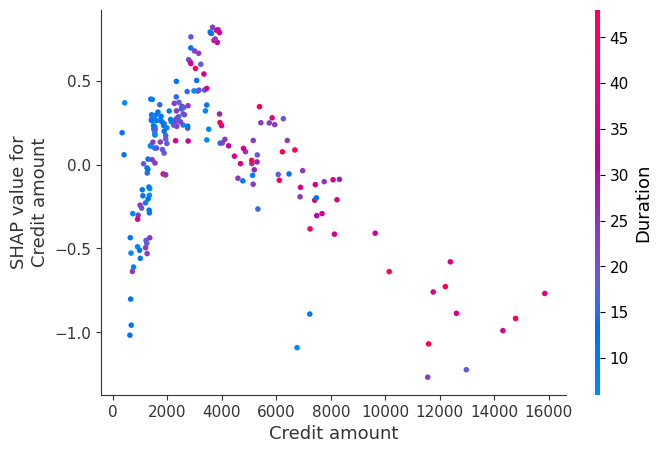

In [38]:
shap.dependence_plot(
    "Credit amount", 
    shap_values, 
    X_test,
    interaction_index="Duration"
)

The strongest interaction is observed between **Credit amount** and **Duration**, indicating that the impact of credit amount on the prediction depends on the loan duration.

The SHAP dependence plot confirms this, as the contribution of **Credit amount** varies significantly across different values of **Duration**. For higher durations, large credit amounts lead to a stronger negative impact on the prediction, whereas for shorter durations, this effect is less pronounced.

The table shows additional interacting pairs, although their interaction strength is weaker, indicating that their effects are closer to additive and less dependent on each other.

For weaker interactions, the dependence plots show less variation across the conditioning feature, indicating limited dependency.

Overall, the model captures dependencies primarily between loan-related variables (**Credit amount**, **Duration**) and financial capacity variables (**Checking account**, **Saving accounts**), indicating that the decision process evaluates criteria jointly rather than independently. However, most interactions are relatively weak, suggesting that the model is still largely additive with a few key dependencies.

### Q4

What is the nature of the criterion, gain, cost, non-monotonic?

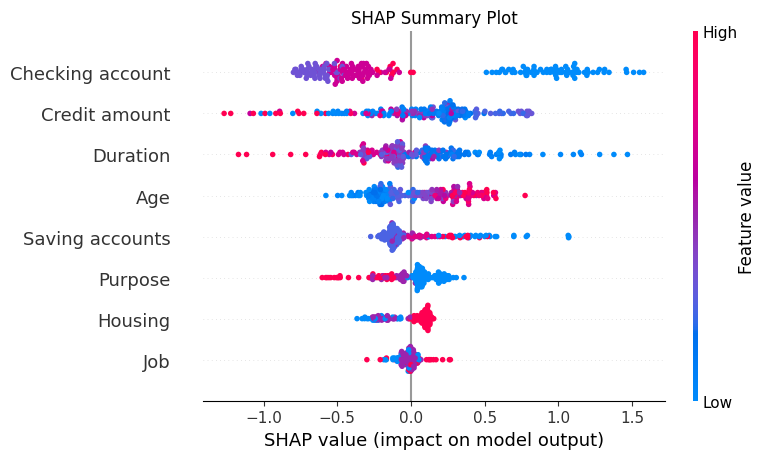

In [39]:
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 45.74it/s]


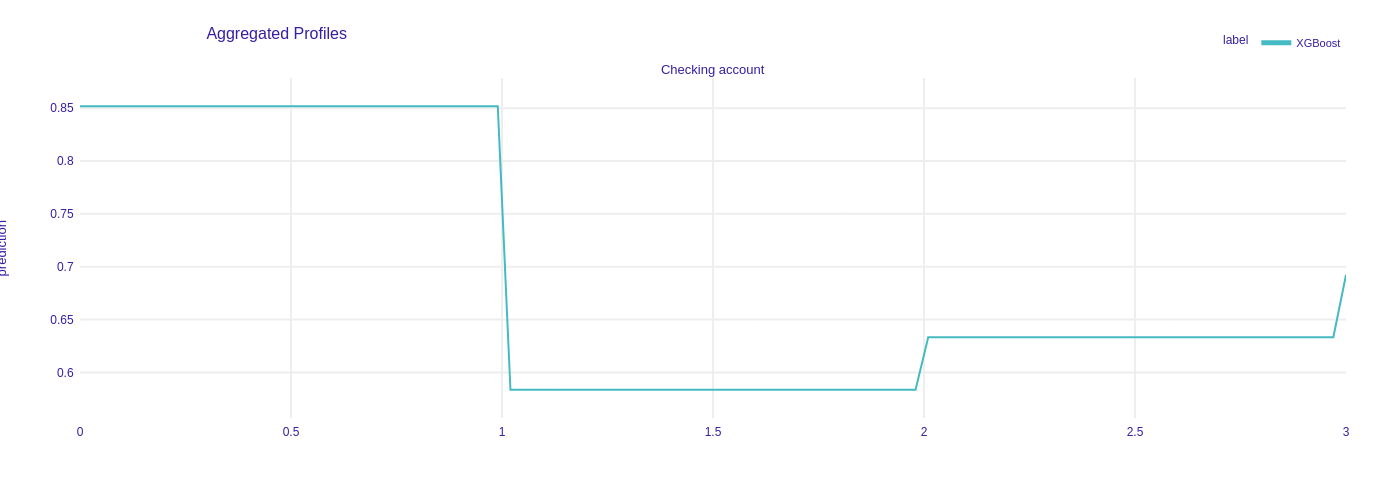

In [40]:
explainer.model_profile(variables=["Checking account"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 48.01it/s]


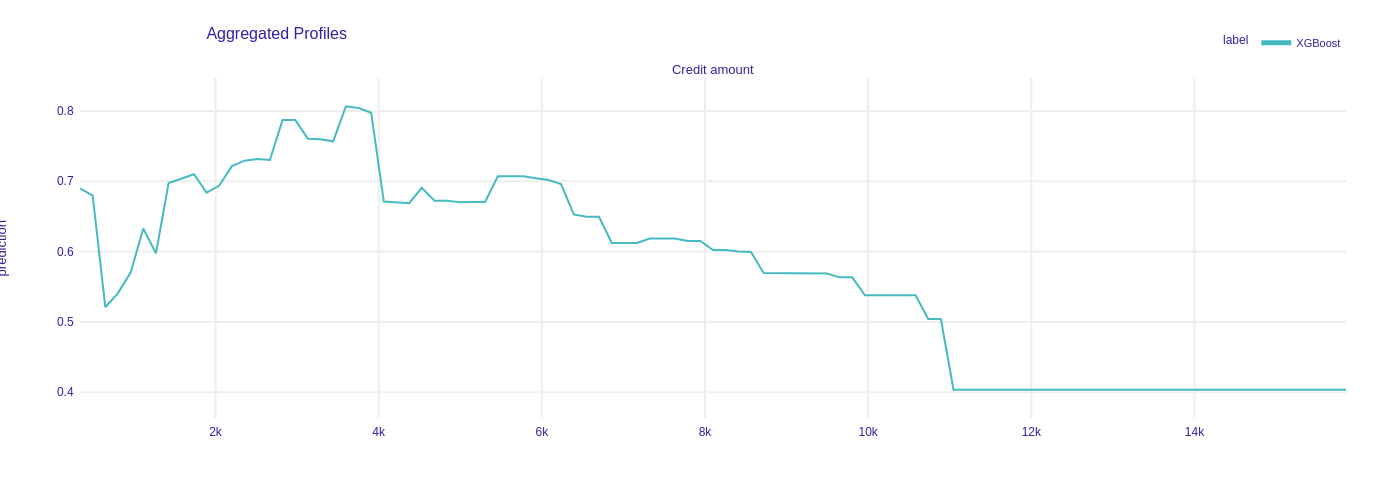

In [41]:
explainer.model_profile(variables=["Credit amount"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 45.89it/s]


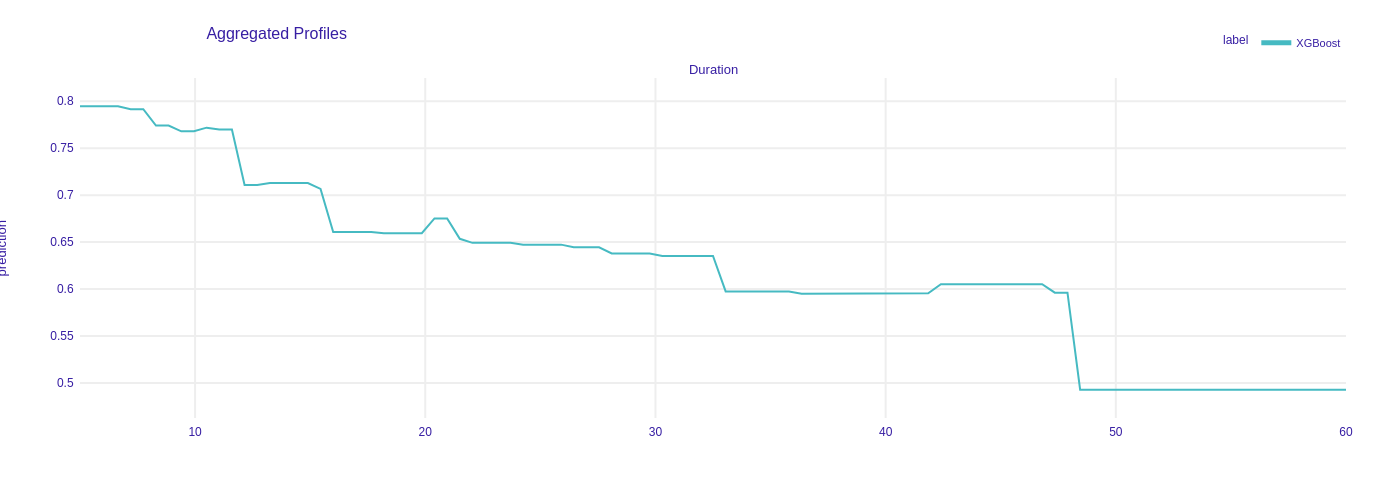

In [42]:
explainer.model_profile(variables=["Duration"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 42.64it/s]


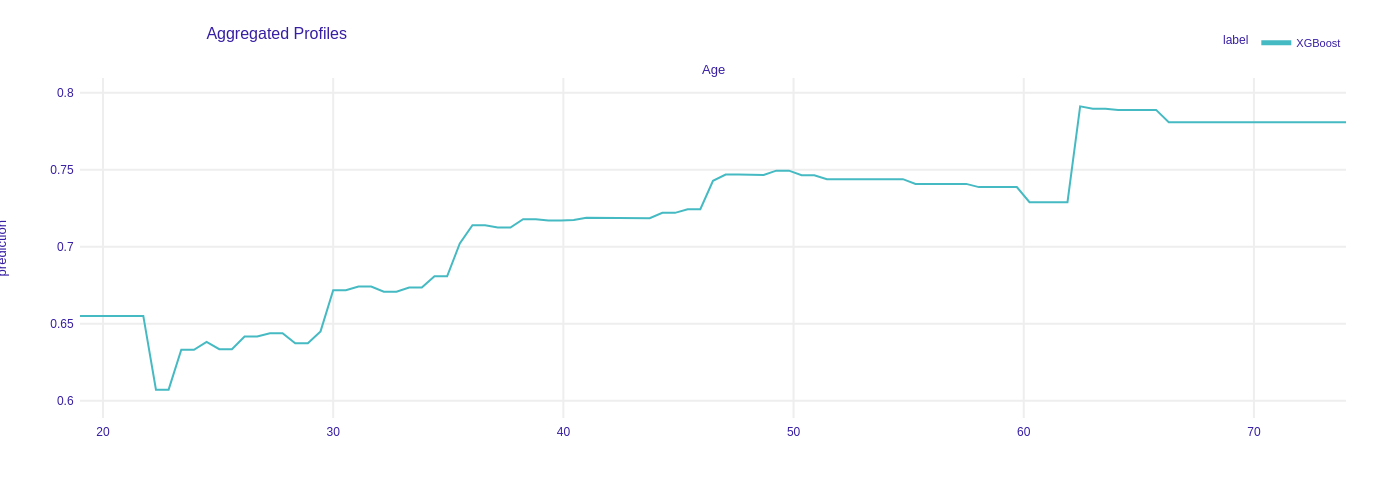

In [43]:
explainer.model_profile(variables=["Age"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 48.48it/s]


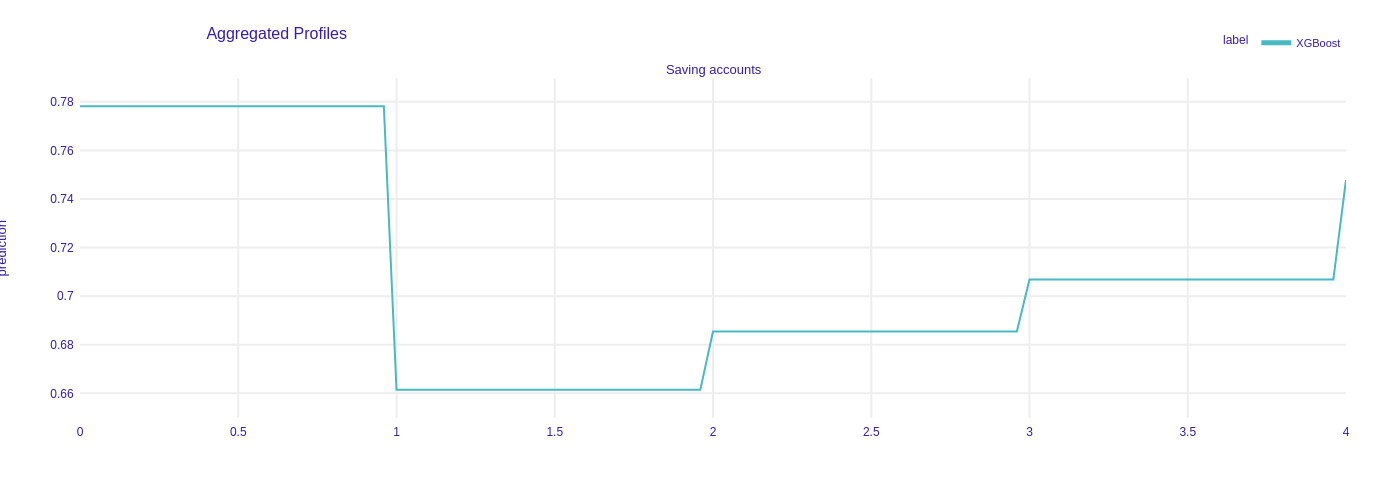

In [44]:
explainer.model_profile(variables=["Saving accounts"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 44.60it/s]


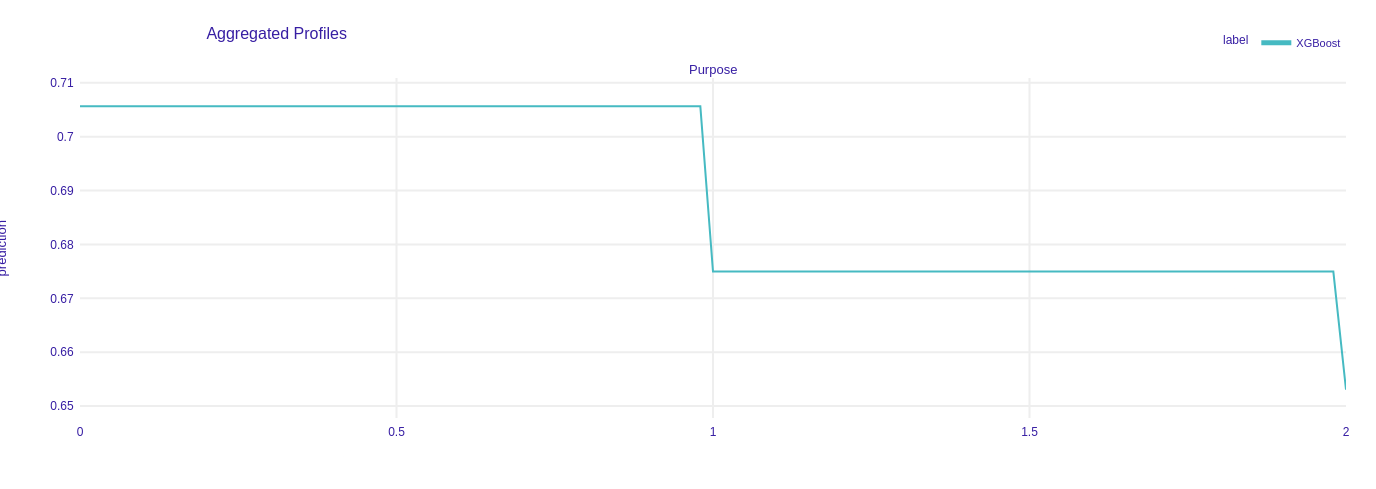

In [45]:
explainer.model_profile(variables=["Purpose"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 49.26it/s]


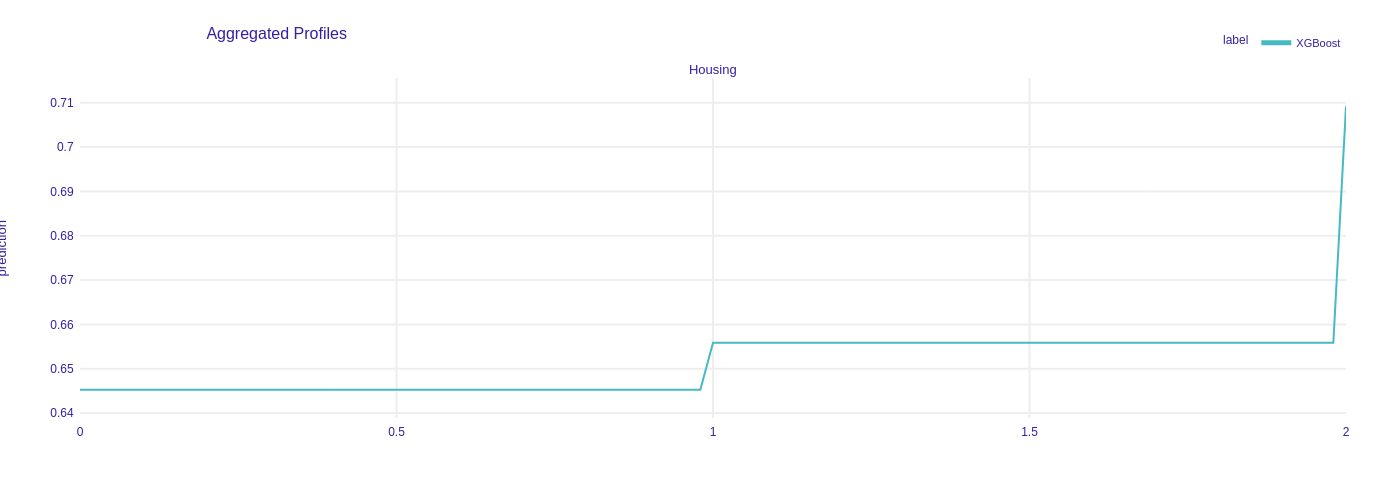

In [46]:
explainer.model_profile(variables=["Housing"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 47.03it/s]


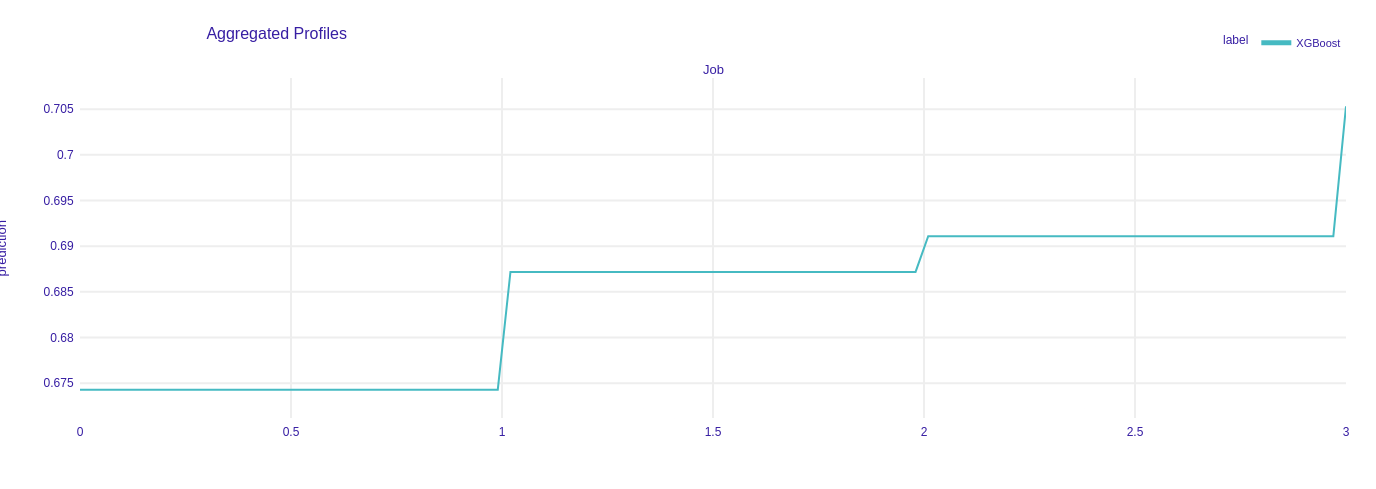

In [47]:
explainer.model_profile(variables=["Job"]).plot()

The nature of the criteria was determined using SHAP summary plots and DALEX partial dependence profiles.

`Checking account` exhibits monotonic behavior for values 1–3, where increasing values correspond to increasingly favorable predictions. However, the value 0 deviates from this trend and is associated with the most positive contribution, breaking strict monotonicity. This indicates a special-case category effect, resulting in overall non-monotonic behavior with a structured pattern.

`Credit amount` behaves primarily as a cost criterion, although noticeable non-monotonicity is present. Mid-range values are associated with more favorable outcomes, while both very low and very high values increase risk, suggesting the existence of an optimal interval rather than a purely monotonic relationship.

`Duration` is a clear cost criterion, with longer durations consistently leading to worse predictions. This is strongly supported by both SHAP values and the decreasing trend in the partial dependence plot.

`Age` exhibits gain-type behavior, as higher values generally contribute positively to the prediction, which is visible in both SHAP value distribution and the upward trend in the partial dependence plot.

`Saving accounts` follows a pattern similar to Checking account, where most categories show an increasing trend in contribution, but for class 0 it deviates from this ordering. This results in structured but not strictly monotonic behavior.

`Purpose` demonstrates a monotonic trend, where higher encoded values are generally associated with less favorable outcomes. Although some variability exists, both SHAP and partial dependence plots indicate an overall cost-type tendency.

`Housing` shows a gain-type tendency, where more stable housing situations correspond to better predictions, the extreme value is highly separated from the rest, while the lower values are more mixed up, showing a moderate monotonocity.

`Job` demonstrates a weak monotonic trend, with higher job categories slightly improving predictions; however, the SHAP distribution indicates that this effect is not strong and may depend on other variables.

Overall, the model combines clearly monotonic cost and gain criteria (Duration, Age, Purpose, Housing) with several criteria that exhibit structured but imperfect monotonicity, often influenced by specific category effects. This suggests that the decision process is largely consistent in direction but includes exceptions driven by particular feature values.

### Q5

Whether there are any preference thresholds? Are there any evaluations on criteria that are indifferent in terms of preferences?

**Thresholds**:

- Categorical variables (`Checking account`, `Saving accounts`, `Purpose`, `Housing`, `Job`) naturally exhibit thresholds at each category value due to the discrete nature of tree-based models like XGBoost.

- `Credit amount` shows a significant threshold around **4k**, where the effect flips from increasing (more favorable) to decreasing (higher risk).

- `Duration` has several thresholds at approximately **12, 16, 32, and 48** months, where the model prediction changes more sharply. These thresholds correspond to splits learned by the trees.

- `Age` shows thresholds at approximately **30, 36, 48, and 62**. While the effect around **62** is interpretable (lower credit risk for older, more stable individuals), the other thresholds may reflect tree splits or potential overfitting in certain ranges.

**Indifference zones**:

- `Duration` and `Age` both have multiple flat regions in the SHAP and PDP plots. This indicates that minor changes in these features within these ranges do not meaningfully
affect the prediction, reflecting regions of indifference.

- The discrete nature of XGBoost's trees explains these flat regions: the model creates splits only at specific thresholds, leaving ranges between splits with nearly constant predictions.

Summary:

Overall, the model captures clear thresholds for categorical and numerical features, along with indifference ranges for numerical features, reflecting both structured decision points and zones where small changes do not alter predicted outcomes. This aligns with the tree-based model logic and the patterns observed in the SHAP and PDP analyses.

## Summary

**2.1 Explanation of Decisions**

Three alternatives were selected for analysis: samples 15, 73, and 118. For each, the prediction was explained using a SHAP waterfall plot, and the minimum single-feature change required to flip the classification was determined both analytically and via sampling.

The analytical method traverses the decision paths of all 100 XGBoost trees, collecting exact split thresholds for each feature and identifying the nearest threshold crossing that flips the predicted class. The sampling method iteratively perturbs a single feature in step increments until the class changes. Both methods agreed exactly on all discrete/ordinal features. For continuous features (`Credit amount`), minor discrepancies appeared - the sampling result was slightly off due to the fixed step size causing the scan to overshoot the true boundary, while the analytical result hit the exact threshold.

Sample 15 (p_good=0.518) is the most uncertain of the three. No feature contributes strongly positively - `Housing` (own) and `Job` (skilled) are the only positive contributors but with negligible magnitude. `Duration` is the dominant negative, with `Checking account`, `Age`, and `Saving accounts` adding further penalties. The prediction stays good credit purely due to the high base value. Both methods agreed: the minimum flip requires a single category step in several ordinal features, making this the easiest profile to push into bad credit.

Sample 73 (p_good=0.565) has a clearer positive profile - short loan duration and mature age contribute strongly positively, with owned housing and leisure purpose adding support. However, `Checking account` (little) alone cancels all positives combined, keeping the margin relatively thin. Both methods agreed on all features.

Sample 118 (p_good=0.510) is the most borderline — only 0.04 from flipping. Age is the sole strong positive, but a weak checking account and a large credit amount dominate negatively. Despite being the oldest and most professionally stable applicant of the three, the combination of a high loan amount and poor checking account status leaves the classification extremely fragile. Both methods agreed on all features.

**2.2 Interpretation of the Model**

The XGBoost model reveals a clear and economically interpretable preference structure. Permutation feature importance and SHAP analysis consistently identify `Checking account`, `Credit amount`, `Duration`, and `Saving accounts` as the decisive criteria, while `Purpose`, `Housing`, and `Job` have negligible influence. `Age` shows an interesting discrepancy - moderately important at the individual level via SHAP, but globally marginal according to permutation importance, suggesting redundancy with other variables.

The dominant criteria exhibit well-defined roles: `Duration` and `Credit amount` act as cost criteria, `Age` and `Housing` as gain criteria, while `Checking account` and `Saving accounts` display structured but non-monotonic behavior driven by category-level effects at value 0. The primary interaction is between `Credit amount` and `Duration`, which the model evaluates jointly - large credit amounts are penalized more heavily when accompanied by long durations.

Clear thresholds are present throughout: categorical variables exhibit natural category-level thresholds, `Credit amount` shows a significant inflection around 4k, `Duration` has sharp transitions at approximately 12, 16, 32, and 48 months, and `Age` shows thresholds at approximately 30, 36, 48, and 62. Flat regions between tree splits create genuine indifference zones for `Duration` and `Age`, where minor changes produce no change in prediction.

Overall, the model reflects a conservative, risk-averse decision policy favoring applicants with strong account liquidity, moderate credit amounts, and short loan durations - a preference structure that is consistent, interpretable, and well-supported across all analysis techniques.